In [1]:
#04 tier selection
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from scipy.cluster.hierarchy import (
    dendrogram,
    linkage,
)

from sklearn.cluster import (
    AgglomerativeClustering,
    KMeans,
)

from sklearn.metrics import (
    adjusted_rand_score,
    calinski_harabasz_score,
    davies_bouldin_score,
    silhouette_score,
)

In [5]:
INPUT_FILE = Path(
    "/Users/cc-hoa/Desktop/毕业论文代码/results/step_03_UHI.xlsx"
)

INPUT_SHEET = "Full_Results"

OUTPUT_DIR = Path(
    "/Users/cc-hoa/Desktop/毕业论文代码/results"
)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

In [6]:
#read UHI
df = pd.read_excel(
    INPUT_FILE,
    sheet_name=INPUT_SHEET,
    engine="openpyxl",
)

df = df.sort_values(
    "UHI",
    ascending=False,
).reset_index(drop=True)

X = df[["UHI"]].to_numpy()

CANDIDATE_K = range(2, 7)

In [7]:
#Convert cluster IDs into an ordered tier
#The group with the highest mean is Tier 1
def order_as_tiers(values, labels):
    temporary = pd.DataFrame({
        "Value": values,
        "Cluster": labels,
    })

    cluster_order = (
        temporary.groupby("Cluster")["Value"]
        .mean()
        .sort_values(ascending=False)
        .index
        .tolist()
    )

    mapping = {
        cluster_label: tier_number
        for tier_number, cluster_label
        in enumerate(cluster_order, start=1)
    }

    ordered_tiers = np.array([
        mapping[label]
        for label in labels
    ])

    return ordered_tiers

In [8]:
#Select an appropriate number of tiers
#Run K-means and Ward for each K
diagnostic_rows = []
assignment_data = df[
    [
        "UHI_rank",
        "ISO3",
        "FUA_Code",
        "FUA_Name",
        "UHI",
    ]
].copy()

summary_rows = []

for k in CANDIDATE_K:
# K-means

    kmeans = KMeans(
        n_clusters=k,
        random_state=2026,
        n_init=100,
    )

    kmeans_labels = kmeans.fit_predict(X)

    kmeans_tiers = order_as_tiers(
        df["UHI"].to_numpy(),
        kmeans_labels,
    )
# Ward

    ward = AgglomerativeClustering(
        n_clusters=k,
        linkage="ward",
    )

    ward_labels = ward.fit_predict(X)

    ward_tiers = order_as_tiers(
        df["UHI"].to_numpy(),
        ward_labels,
    )

    assignment_data[
        f"KMeans_Tier_k{k}"
    ] = kmeans_tiers

    assignment_data[
        f"Ward_Tier_k{k}"
    ] = ward_tiers

# Verify the robustness of K-means classification
    silhouette = silhouette_score(
        X,
        kmeans_labels,
    )

    calinski_harabasz = (
        calinski_harabasz_score(
            X,
            kmeans_labels,
        )
    )

    davies_bouldin = (
        davies_bouldin_score(
            X,
            kmeans_labels,
        )
    )

    ari = adjusted_rand_score(
        kmeans_labels,
        ward_labels,
    )

    cluster_sizes = (
        pd.Series(kmeans_tiers)
        .value_counts()
        .sort_index()
    )

    diagnostic_rows.append({
        "K": k,
        "KMeans_Inertia": kmeans.inertia_,
        "Silhouette": silhouette,
        "Calinski_Harabasz": calinski_harabasz,
        "Davies_Bouldin": davies_bouldin,
        "KMeans_Ward_ARI": ari,
        "Minimum_Tier_Size": (
            cluster_sizes.min()
        ),
        "Maximum_Tier_Size": (
            cluster_sizes.max()
        ),
        "Tier_Sizes": "; ".join(
            f"T{tier}={size}"
            for tier, size
            in cluster_sizes.items()
        ),
    })

#Tier Overview for Each Candidate K
    temporary = df.copy()
    temporary["Tier"] = kmeans_tiers

    tier_summary = (
        temporary.groupby("Tier")["UHI"]
        .agg([
            "count",
            "mean",
            "min",
            "max",
        ])
        .reset_index()
    )
    for _, row in tier_summary.iterrows():
        summary_rows.append({
            "K": k,
            "Tier": int(row["Tier"]),
            "Number_of_Cities": int(
                row["count"]
            ),
            "Mean_UHI": row["mean"],
            "Minimum_UHI": row["min"],
            "Maximum_UHI": row["max"],
        })

diagnostics = pd.DataFrame(
    diagnostic_rows
)

tier_summaries = pd.DataFrame(
    summary_rows
)

In [10]:
#Display Diagnostic Results
display(diagnostics)
display(tier_summaries)

with pd.ExcelWriter(
    OUTPUT_DIR / "step_04_Tier_Diagnostics.xlsx",
    engine="openpyxl",
) as writer:

    diagnostics.to_excel(
        writer,
        sheet_name="Diagnostics",
        index=False,
    )

    tier_summaries.to_excel(
        writer,
        sheet_name="Tier_Summary",
        index=False,
    )

,K,KMeans_Inertia,Silhouette,Calinski_Harabasz,Davies_Bouldin,KMeans_Ward_ARI,Minimum_Tier_Size,Maximum_Tier_Size,Tier_Sizes
0,2,12.818,0.652,130.042,0.430,1.000,13,43,T1=13; T2=43
1,3,4.860,0.603,211.700,0.469,0.882,13,24,T1=13; T2=24; T3=19
2,4,3.168,0.578,221.648,0.457,0.860,12,16,T1=12; T2=16; T3=13; T4=15
3,5,1.813,0.577,294.470,0.510,0.900,5,15,T1=5; T2=8; T3=15; T4=13; T5=15
4,6,1.309,0.587,323.853,0.496,1.000,5,15,T1=5; T2=8; T3=15; T4=11; T5=8; T6=9


,K,Tier,Number_of_Cities,Mean_UHI,Minimum_UHI,Maximum_UHI
0,2,1,13,1.350,0.750,2.251
1,2,2,43,-0.408,-1.295,0.417
2,3,1,13,1.350,0.750,2.251
3,3,2,24,-0.025,-0.447,0.417
4,3,3,19,-0.892,-1.295,-0.479
5,4,1,12,1.400,0.937,2.251
6,4,2,16,0.187,-0.063,0.750
7,4,3,13,-0.391,-0.646,-0.198
8,4,4,15,-0.981,-1.295,-0.701
9,5,1,5,1.766,1.524,2.251


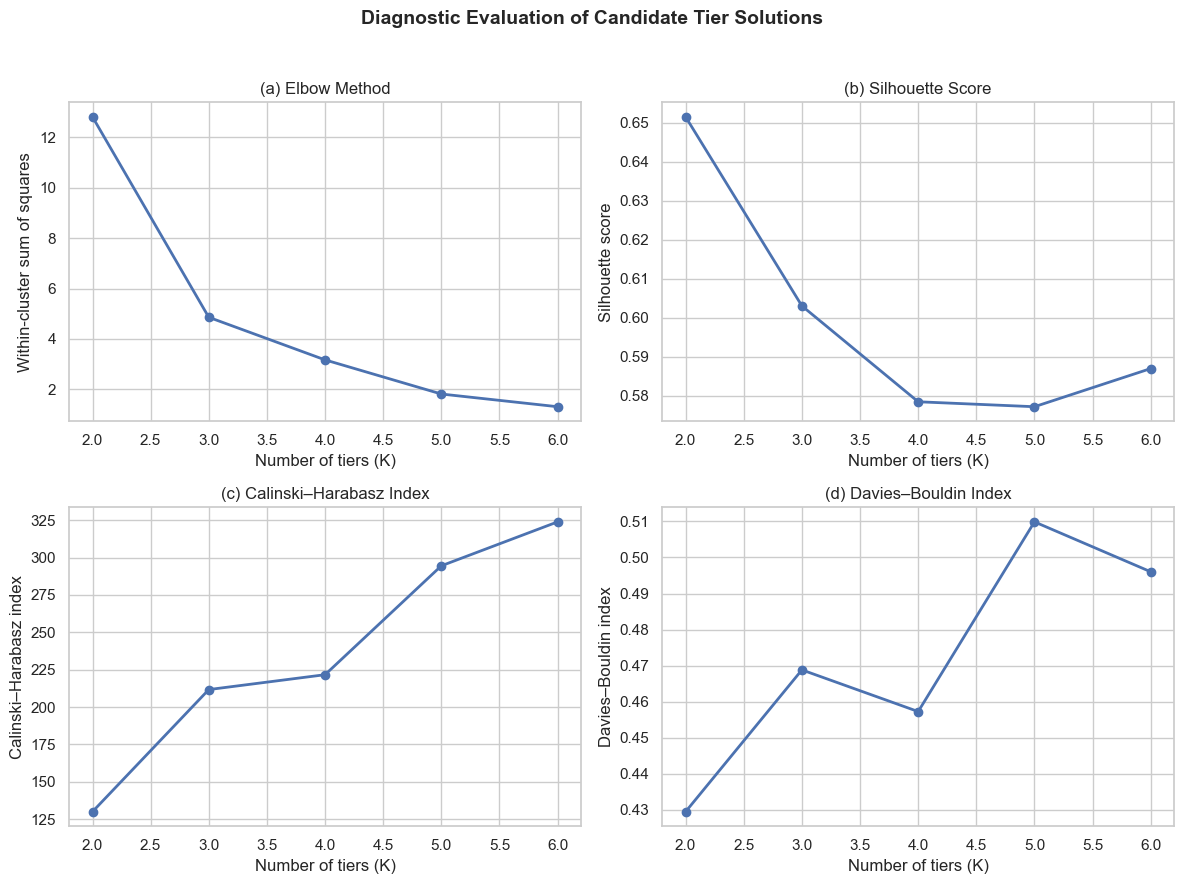

PNG saved to: /Users/cc-hoa/Desktop/毕业论文代码/results/Figure_4_Tier_Diagnostics.png
PDF saved to: /Users/cc-hoa/Desktop/毕业论文代码/results/Figure_4_Tier_Diagnostics.pdf


In [13]:
#Diagnostic Figures for Candidate Tier Solutions
sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(
    2,
    2,
    figsize=(12, 9),
)
# (a) Elbow Method
axes[0, 0].plot(
    diagnostics["K"],
    diagnostics["KMeans_Inertia"],
    marker="o",
    linewidth=2,
)

axes[0, 0].set_title(
    "(a) Elbow Method",
    fontsize=12,
)

axes[0, 0].set_xlabel(
    "Number of tiers (K)"
)

axes[0, 0].set_ylabel(
    "Within-cluster sum of squares"
)

# (b) Silhouette Score
axes[0, 1].plot(
    diagnostics["K"],
    diagnostics["Silhouette"],
    marker="o",
    linewidth=2,
)

axes[0, 1].set_title(
    "(b) Silhouette Score",
    fontsize=12,
)

axes[0, 1].set_xlabel(
    "Number of tiers (K)"
)

axes[0, 1].set_ylabel(
    "Silhouette score"
)

# (c) Calinski–Harabasz Index
axes[1, 0].plot(
    diagnostics["K"],
    diagnostics["Calinski_Harabasz"],
    marker="o",
    linewidth=2,
)

axes[1, 0].set_title(
    "(c) Calinski–Harabasz Index",
    fontsize=12,
)

axes[1, 0].set_xlabel(
    "Number of tiers (K)"
)

axes[1, 0].set_ylabel(
    "Calinski–Harabasz index"
)

# (d) Davies–Bouldin Index
axes[1, 1].plot(
    diagnostics["K"],
    diagnostics["Davies_Bouldin"],
    marker="o",
    linewidth=2,
)

axes[1, 1].set_title(
    "(d) Davies–Bouldin Index",
    fontsize=12,
)

axes[1, 1].set_xlabel(
    "Number of tiers (K)"
)

axes[1, 1].set_ylabel(
    "Davies–Bouldin index"
)

# Figure Layout
fig.suptitle(
    "Diagnostic Evaluation of Candidate Tier Solutions",
    fontsize=14,
    fontweight="bold",
)

fig.tight_layout(rect=[0, 0, 1, 0.96])

# Save Figures
PNG_FILE = OUTPUT_DIR / "Figure_4_Tier_Diagnostics.png"

PDF_FILE = OUTPUT_DIR / "Figure_4_Tier_Diagnostics.pdf"

fig.savefig(
    PNG_FILE,
    dpi=600,
    bbox_inches="tight",
)

fig.savefig(
    PDF_FILE,
    bbox_inches="tight",
)

plt.show()
plt.close(fig)

print(f"PNG saved to: {PNG_FILE}")
print(f"PDF saved to: {PDF_FILE}")

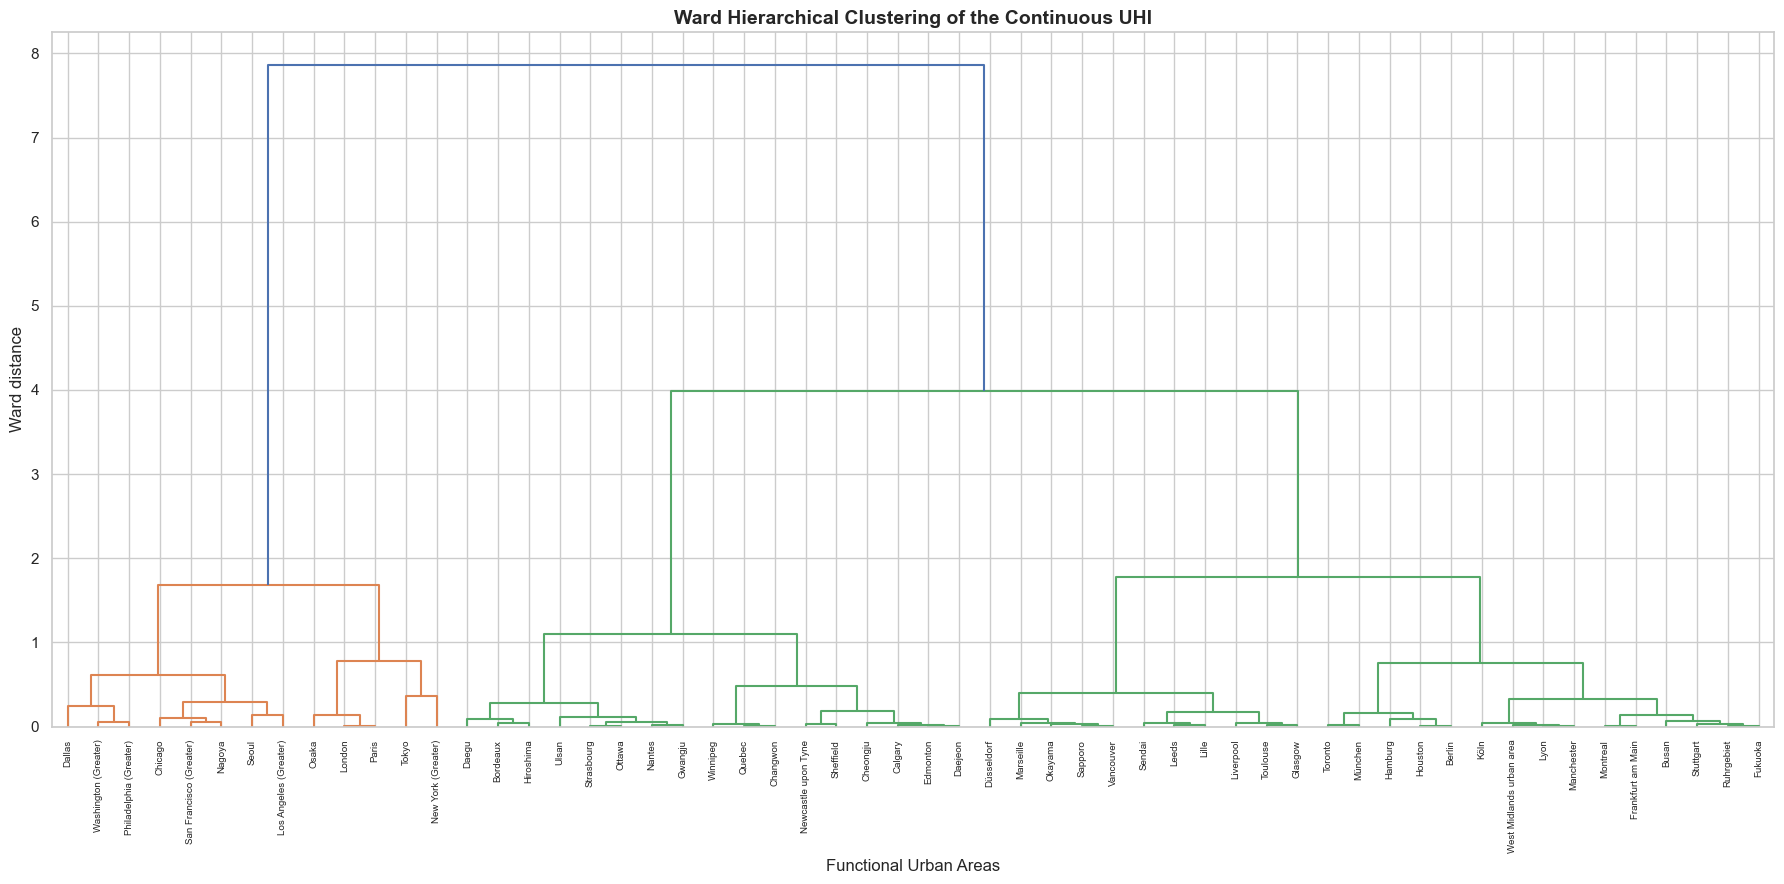

In [14]:
# 8. Ward Hierarchical Clustering Dendrogram
ward_linkage = linkage(
    X,
    method="ward",
)

fig, axis = plt.subplots(
    figsize=(18, 9),
)

dendrogram(
    ward_linkage,
    labels=df["FUA_Name"].to_numpy(),
    leaf_rotation=90,
    leaf_font_size=7,
    color_threshold=None,
    ax=axis,
)

axis.set_title(
    "Ward Hierarchical Clustering of the Continuous UHI",
    fontsize=14,
    fontweight="bold",
)

axis.set_xlabel(
    "Functional Urban Areas"
)

axis.set_ylabel(
    "Ward distance"
)

fig.tight_layout()

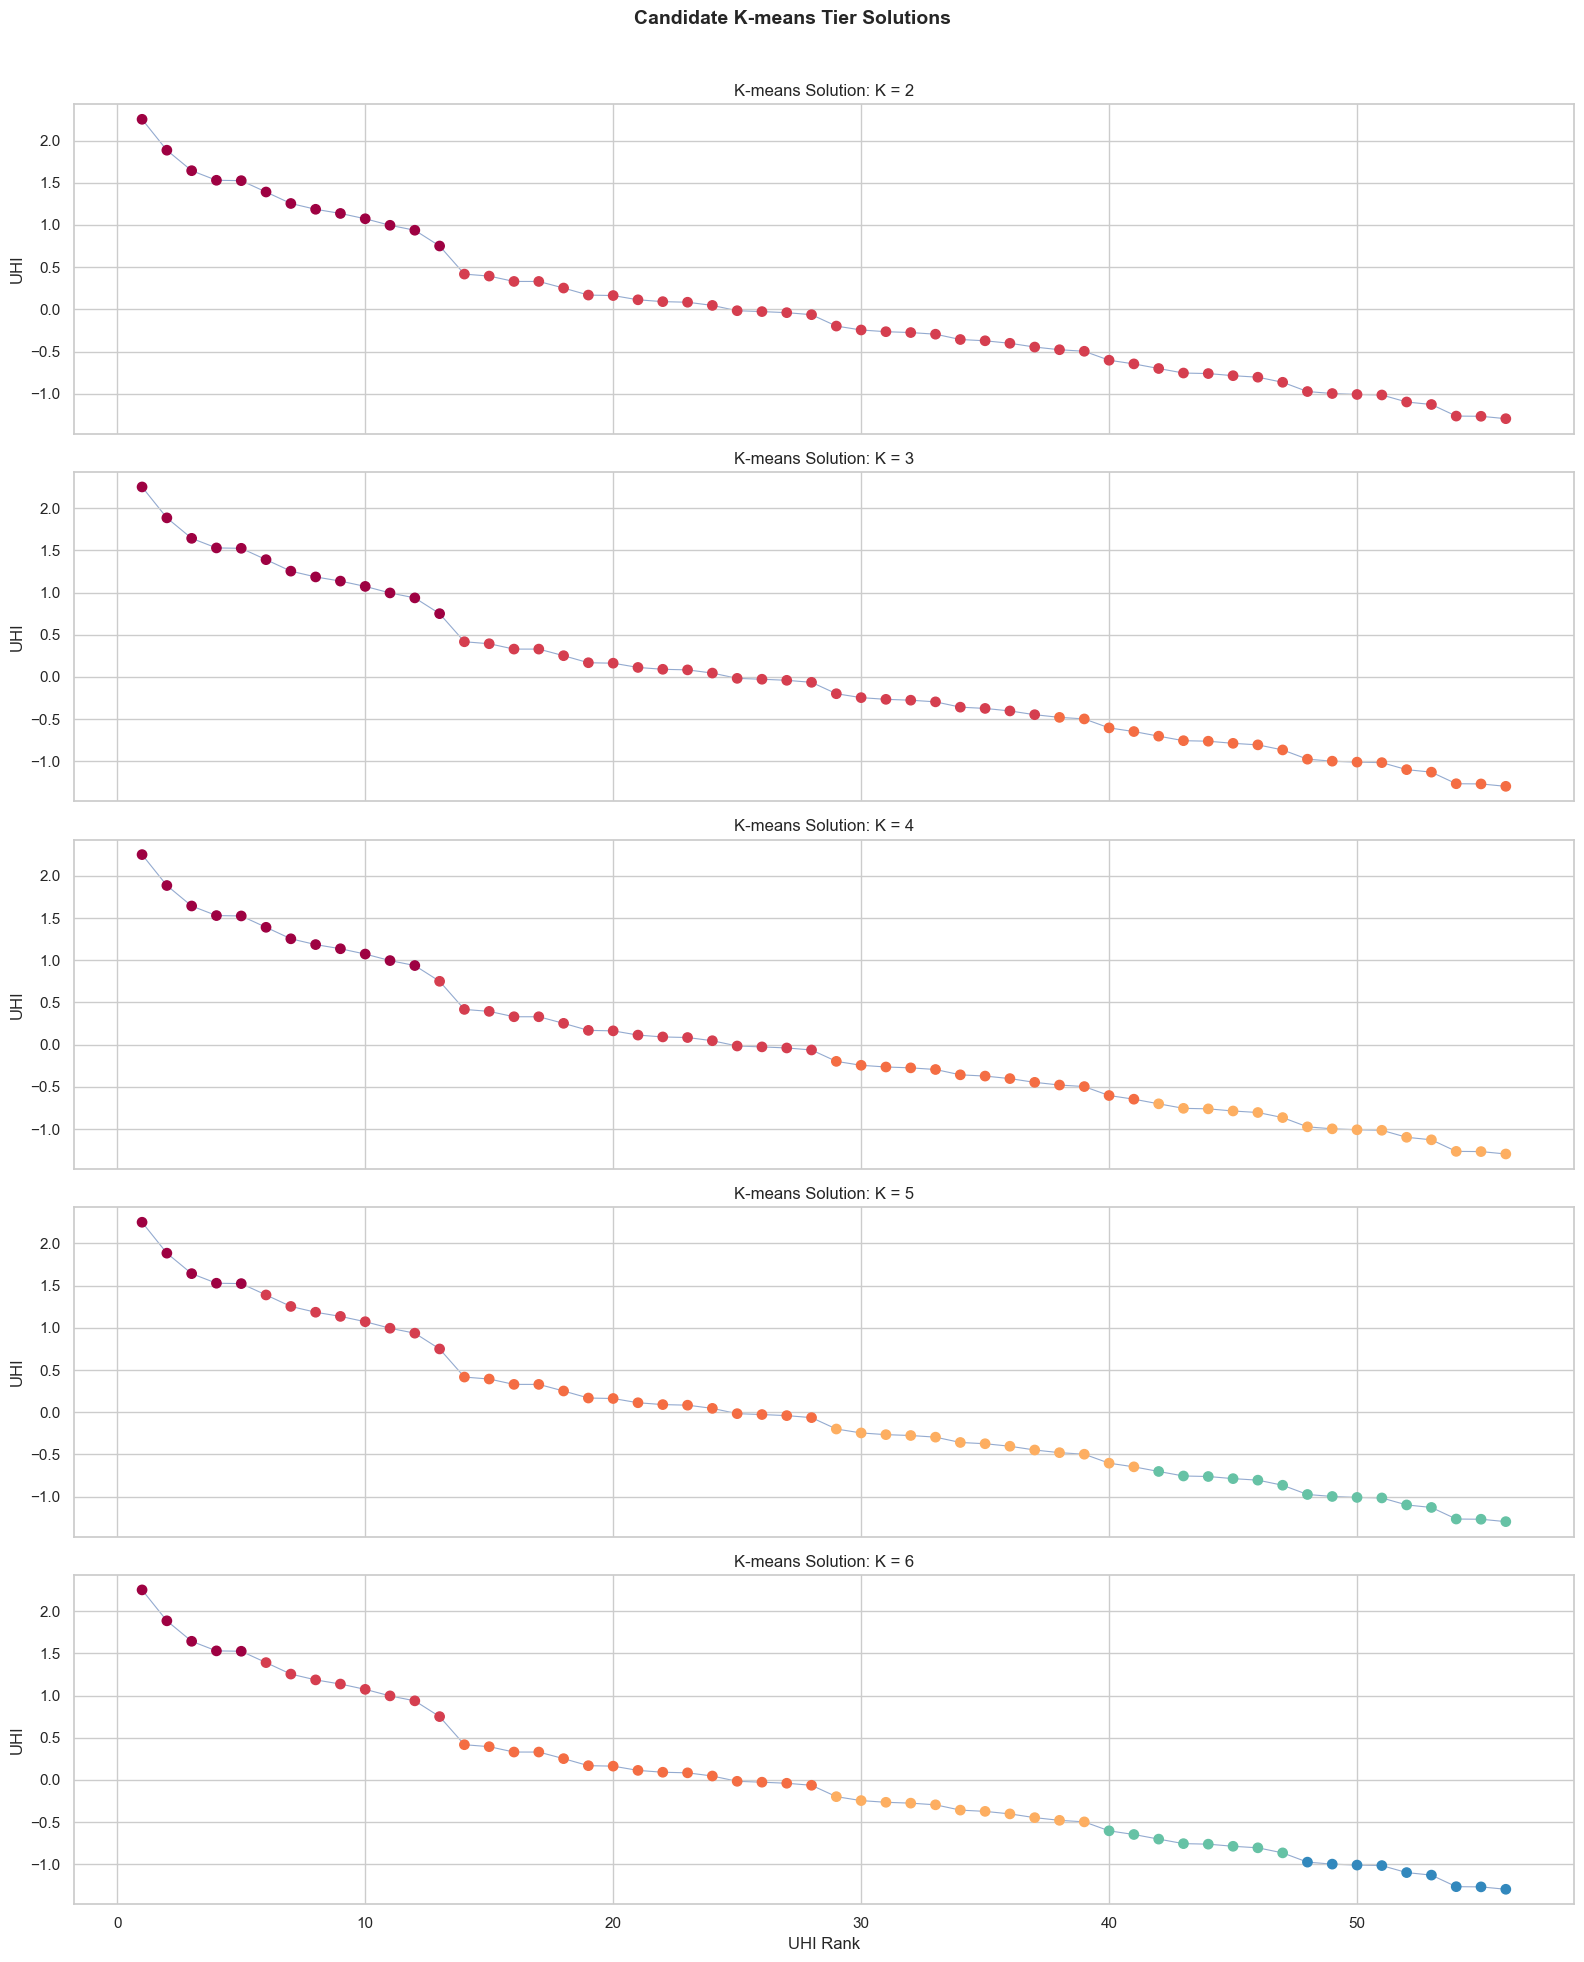

PNG saved to: /Users/cc-hoa/Desktop/毕业论文代码/results/Candidate_KMeans_Tier_Solutions.png
PDF saved to: /Users/cc-hoa/Desktop/毕业论文代码/results/Candidate_KMeans_Tier_Solutions.pdf


In [15]:
# 9. Visualise Candidate K-means Tier Solutions
fig, axes = plt.subplots(
    nrows=5,
    ncols=1,
    figsize=(16, 20),
    sharex=True,
)

tier_palette = {
    1: "#9E0142",
    2: "#D53E4F",
    3: "#F46D43",
    4: "#FDAE61",
    5: "#66C2A5",
    6: "#3288BD",
}

for axis, k in zip(
    axes,
    CANDIDATE_K,
):
    tier_column = f"KMeans_Tier_k{k}"

    colours = (
        assignment_data[tier_column]
        .map(tier_palette)
    )

    axis.scatter(
        assignment_data["UHI_rank"],
        assignment_data["UHI"],
        c=colours,
        s=45,
    )

    axis.plot(
        assignment_data["UHI_rank"],
        assignment_data["UHI"],
        linewidth=0.8,
        alpha=0.6,
        zorder=0,
    )

    axis.set_title(
        f"K-means Solution: K = {k}",
        fontsize=12,
    )

    axis.set_ylabel(
        "UHI"
    )

axes[-1].set_xlabel(
    "UHI Rank"
)

fig.suptitle(
    "Candidate K-means Tier Solutions",
    fontsize=14,
    fontweight="bold",
)

fig.tight_layout(
    rect=[0, 0, 1, 0.97]
)
# Save Figure
CANDIDATE_PNG = (
    OUTPUT_DIR
    / "Candidate_KMeans_Tier_Solutions.png"
)

CANDIDATE_PDF = (
    OUTPUT_DIR
    / "Candidate_KMeans_Tier_Solutions.pdf"
)

fig.savefig(
    CANDIDATE_PNG,
    dpi=600,
    bbox_inches="tight",
)

fig.savefig(
    CANDIDATE_PDF,
    bbox_inches="tight",
)

plt.show()
plt.close(fig)

print(f"PNG saved to: {CANDIDATE_PNG}")
print(f"PDF saved to: {CANDIDATE_PDF}")

In [16]:
# Final number of tiers selected
FINAL_K = 4
# 2. Read UHI for Final Tier Classification
df = pd.read_excel(
    INPUT_FILE,
    sheet_name=INPUT_SHEET,
    engine="openpyxl",
)

X = df[["UHI"]].to_numpy()

In [17]:
#Convert unordered cluster IDs into ordered tiers
def order_as_tiers(values, labels):
    temporary = pd.DataFrame({
        "UHI": values,
        "Cluster": labels,
    })

    cluster_order = (
        temporary.groupby("Cluster")["UHI"]
        .mean()
        .sort_values(ascending=False)
        .index
        .tolist()
    )

    mapping = {
        cluster_label: tier_number
        for tier_number, cluster_label
        in enumerate(cluster_order, start=1)
    }

    return np.array([
        mapping[label]
        for label in labels
    ])

In [18]:
#K-means
kmeans = KMeans(
    n_clusters=FINAL_K,
    random_state=2026,
    n_init=100,
)

kmeans_labels = kmeans.fit_predict(X)

df["Tier_KMeans"] = order_as_tiers(
    df["UHI"].to_numpy(),
    kmeans_labels,
)

In [19]:
#Robustness Check: Ward Hierarchical Clustering
ward = AgglomerativeClustering(
    n_clusters=FINAL_K,
    linkage="ward",
)

ward_labels = ward.fit_predict(X)

df["Tier_Ward"] = order_as_tiers(
    df["UHI"].to_numpy(),
    ward_labels,
)

In [20]:
# 6. Validation of K-means Tier Classification
ari = adjusted_rand_score(
    df["Tier_KMeans"],
    df["Tier_Ward"],
)

df["Tier_Agreement"] = np.where(
    df["Tier_KMeans"] == df["Tier_Ward"],
    "Same",
    "Different",
)

agreement_rate = (
    df["Tier_Agreement"]
      .eq("Same")
      .mean()
)

agreement_summary = pd.DataFrame({
    "Metric": [
        "Adjusted Rand Index",
        "Agreement Rate",
    ],
    "Value": [
        ari,
        agreement_rate,
    ],
})

display(agreement_summary)

agreement_summary.to_excel(
    OUTPUT_DIR / "Step_04_Ward_Validation.xlsx",
    index=False,
)

,Metric,Value
0,Adjusted Rand Index,0.860
1,Agreement Rate,0.946


In [21]:
# 7. Sort Final Results by Tier and UHI
df = df.sort_values(
    [
        "Tier_KMeans",
        "UHI",
    ],
    ascending=[
        True,
        False,
    ],
).reset_index(drop=True)

In [22]:
# 8. Summary Statistics for Final Tier Classification
tier_summary = (
    df.groupby("Tier_KMeans")
    .agg(
        Number_of_Cities=("FUA_Code", "count"),
        Mean_UHI=("UHI", "mean"),
        Median_UHI=("UHI", "median"),
        Minimum_UHI=("UHI", "min"),
        Maximum_UHI=("UHI", "max"),
        Mean_DEM=("DEM_star", "mean"),
        Mean_ECO=("ECO_star", "mean"),
        Mean_TRA=("TRA_star", "mean"),
        Mean_FUN=("FUN_star", "mean"),
    )
    .reset_index()
    .rename(
        columns={
            "Tier_KMeans": "Tier",
        }
    )
)

display(tier_summary)

tier_summary.to_excel(
    OUTPUT_DIR / "Step_04_Tier_Summary.xlsx",
    index=False,
)

,Tier,Number_of_Cities,Mean_UHI,Median_UHI,Minimum_UHI,Maximum_UHI,Mean_DEM,Mean_ECO,Mean_TRA,Mean_FUN
0,1,12,1.400,1.322,0.937,2.251,1.535,1.260,1.361,1.445
1,2,16,0.187,0.138,-0.063,0.750,0.189,0.286,0.114,0.161
2,3,13,-0.391,-0.372,-0.646,-0.198,-0.553,-0.597,-0.106,-0.307
3,4,15,-0.981,-0.997,-1.295,-0.701,-0.949,-0.796,-1.118,-1.062


In [25]:
print(df.columns.tolist())

['ID', 'Country', 'ISO3', 'Rank_in_Country', 'FUA_Code', 'FUA_Name', 'Core_City', 'DEM_raw', 'ECO_raw', 'TRA_raw', 'FUN_raw', 'DEM_star', 'ECO_star', 'TRA_star', 'FUN_star', 'DEM_rank', 'ECO_rank', 'TRA_rank', 'FUN_rank', 'DEM_contribution', 'ECO_contribution', 'TRA_contribution', 'FUN_contribution', 'UHI', 'UHI_z', 'UHI_rank', 'Within_country_rank', 'Tier_KMeans', 'Tier_Ward', 'Tier_Agreement']


In [26]:
# 9. Final Tier Classification Results
# Full results, including validation variables
tier_results = df[
    [
        "UHI_rank",
        "Within_country_rank",
        "Country",
        "ISO3",
        "FUA_Code",
        "FUA_Name",
        "Core_City",
        "UHI",
        "UHI_z",
        "DEM_star",
        "ECO_star",
        "TRA_star",
        "FUN_star",
        "Tier_KMeans",
        "Tier_Ward",
        "Tier_Agreement",
    ]
].copy()

display(tier_results)

# Save Full Tier Results
FULL_RESULTS_FILE = (
    OUTPUT_DIR
    / "Step_04_Final_Tier_Results.xlsx"
)

tier_results.to_excel(
    FULL_RESULTS_FILE,
    index=False,
)

# Create Dataset for Subsequent Analysis
analysis_results = tier_results.drop(
    columns=[
        "Tier_Ward",
        "Tier_Agreement",
    ]
).copy()

display(analysis_results)

# Save Analysis Dataset
ANALYSIS_FILE = (
    OUTPUT_DIR
    / "Step_04_Analysis_Dataset.xlsx"
)

analysis_results.to_excel(
    ANALYSIS_FILE,
    index=False,
)


print(
    f"Full tier results saved to: "
    f"{FULL_RESULTS_FILE}"
)

print(
    f"Analysis dataset saved to: "
    f"{ANALYSIS_FILE}"
)

,UHI_rank,Within_country_rank,Country,ISO3,FUA_Code,FUA_Name,Core_City,UHI,UHI_z,DEM_star,ECO_star,TRA_star,FUN_star,Tier_KMeans,Tier_Ward,Tier_Agreement
0,1,1,Japan,JPN,JPN01F,Tokyo,Tokyo,2.251,2.526,2.593,1.043,2.546,2.822,1,1,Same
1,2,1,United States,USA,USA01F,New York (Greater),New York (Greater),1.885,2.115,1.984,2.060,2.177,1.318,1,1,Same
2,3,2,Japan,JPN,JPN02F,Osaka,Osaka,1.643,1.843,1.793,0.200,2.188,2.390,1,1,Same
3,4,1,United Kingdom,GBR,UK001F,London,London,1.529,1.716,1.454,1.535,1.823,1.303,1,1,Same
4,5,1,France,FRA,FR001F,Paris,Paris,1.524,1.711,1.524,1.679,1.109,1.786,1,1,Same
5,6,1,South Korea,KOR,KOR01F,Seoul,Seoul,1.390,1.560,2.165,0.830,0.727,1.838,1,1,Same
6,7,2,United States,USA,USA02F,Los Angeles (Greater),Los Angeles (Greater),1.254,1.407,1.829,1.364,0.525,1.297,1,1,Same
7,8,3,United States,USA,USA05F,San Francisco (Greater),San Francisco (Greater),1.185,1.330,0.806,2.634,0.684,0.617,1,1,Same
8,9,3,Japan,JPN,JPN03F,Nagoya,Nagoya,1.136,1.275,1.096,0.238,1.789,1.421,1,1,Same
9,10,4,United States,USA,USA03F,Chicago,Chicago,1.073,1.204,1.192,1.164,1.094,0.842,1,1,Same


,UHI_rank,Within_country_rank,Country,ISO3,FUA_Code,FUA_Name,Core_City,UHI,UHI_z,DEM_star,ECO_star,TRA_star,FUN_star,Tier_KMeans
0,1,1,Japan,JPN,JPN01F,Tokyo,Tokyo,2.251,2.526,2.593,1.043,2.546,2.822,1
1,2,1,United States,USA,USA01F,New York (Greater),New York (Greater),1.885,2.115,1.984,2.060,2.177,1.318,1
2,3,2,Japan,JPN,JPN02F,Osaka,Osaka,1.643,1.843,1.793,0.200,2.188,2.390,1
3,4,1,United Kingdom,GBR,UK001F,London,London,1.529,1.716,1.454,1.535,1.823,1.303,1
4,5,1,France,FRA,FR001F,Paris,Paris,1.524,1.711,1.524,1.679,1.109,1.786,1
5,6,1,South Korea,KOR,KOR01F,Seoul,Seoul,1.390,1.560,2.165,0.830,0.727,1.838,1
6,7,2,United States,USA,USA02F,Los Angeles (Greater),Los Angeles (Greater),1.254,1.407,1.829,1.364,0.525,1.297,1
7,8,3,United States,USA,USA05F,San Francisco (Greater),San Francisco (Greater),1.185,1.330,0.806,2.634,0.684,0.617,1
8,9,3,Japan,JPN,JPN03F,Nagoya,Nagoya,1.136,1.275,1.096,0.238,1.789,1.421,1
9,10,4,United States,USA,USA03F,Chicago,Chicago,1.073,1.204,1.192,1.164,1.094,0.842,1


Full tier results saved to: /Users/cc-hoa/Desktop/毕业论文代码/results/Step_04_Final_Tier_Results.xlsx
Analysis dataset saved to: /Users/cc-hoa/Desktop/毕业论文代码/results/Step_04_Analysis_Dataset.xlsx


In [27]:
# 10. Cities Assigned to Different Tiers by K-means and Ward
disagreement_cities = tier_results.loc[
    tier_results["Tier_Agreement"] == "Different"
].copy()

display(disagreement_cities)

DISAGREEMENT_FILE = (
    OUTPUT_DIR
    / "Step_04_Disagreement_Cities.xlsx"
)

disagreement_cities.to_excel(
    DISAGREEMENT_FILE,
    index=False,
)

print(
    f"Disagreement cities saved to: "
    f"{DISAGREEMENT_FILE}"
)

,UHI_rank,Within_country_rank,Country,ISO3,FUA_Code,FUA_Name,Core_City,UHI,UHI_z,DEM_star,ECO_star,TRA_star,FUN_star,Tier_KMeans,Tier_Ward,Tier_Agreement
12,13,7,United States,USA,USA07F,Dallas,Dallas,0.750,0.842,1.015,0.978,0.363,0.646,2,1,Different
39,40,6,France,FRA,FR005F,Bordeaux,Bordeaux,-0.603,-0.677,-0.786,-0.546,-0.750,-0.329,3,4,Different
40,41,8,Japan,JPN,JPN08F,Hiroshima,Hiroshima,-0.646,-0.725,-0.751,-1.066,-0.652,-0.116,3,4,Different


Disagreement cities saved to: /Users/cc-hoa/Desktop/毕业论文代码/results/Step_04_Disagreement_Cities.xlsx


In [28]:
# 11. Cross-tabulation of K-means and Ward Tier Assignments
#可以放附录里解释
method_cross_table = pd.crosstab(
    df["Tier_KMeans"],
    df["Tier_Ward"],
    rownames=["K-means Tier"],
    colnames=["Ward Tier"],
)

display(method_cross_table)

CROSSTAB_FILE = (
    OUTPUT_DIR
    / "Step_04_KMeans_Ward_CrossTable.xlsx"
)

method_cross_table.to_excel(
    CROSSTAB_FILE,
)

print(
    f"Cross-table saved to: "
    f"{CROSSTAB_FILE}"
)

Ward Tier,1,2,3,4
K-means Tier,,,,
1,12,0,0,0
2,1,15,0,0
3,0,0,11,2
4,0,0,0,15


Cross-table saved to: /Users/cc-hoa/Desktop/毕业论文代码/results/Step_04_KMeans_Ward_CrossTable.xlsx


In [31]:
#Tier Composition by Country
# Number of cities in each tier by country
country_tier_counts = pd.crosstab(
    df["Country"],
    df["Tier_KMeans"],
)

country_tier_counts.columns = [
    f"Tier_{column}"
    for column in country_tier_counts.columns
]


# Share of cities in each tier within each country
country_tier_shares = pd.crosstab(
    df["Country"],
    df["Tier_KMeans"],
    normalize="index",
)

country_tier_shares.columns = [
    f"Tier_{column}"
    for column in country_tier_shares.columns
]


# Display results
display(country_tier_counts)
display(country_tier_shares)

# Save Results
COUNTRY_TIER_FILE = (
    OUTPUT_DIR
    / "Step_04_Country_Tier_Composition.xlsx"
)

with pd.ExcelWriter(
    COUNTRY_TIER_FILE,
    engine="openpyxl",
) as writer:

    country_tier_counts.to_excel(
        writer,
        sheet_name="Counts",
    )

    country_tier_shares.to_excel(
        writer,
        sheet_name="Shares",
    )


print(
    f"Country tier composition saved to: "
    f"{COUNTRY_TIER_FILE}"
)

,Tier_1,Tier_2,Tier_3,Tier_4
Country,,,,
Canada,0,2,1,5
France,1,1,4,2
Germany,0,7,1,0
Japan,3,1,4,0
South Korea,1,1,0,6
United Kingdom,1,2,3,2
United States,6,2,0,0


,Tier_1,Tier_2,Tier_3,Tier_4
Country,,,,
Canada,0.000,0.250,0.125,0.625
France,0.125,0.125,0.500,0.250
Germany,0.000,0.875,0.125,0.000
Japan,0.375,0.125,0.500,0.000
South Korea,0.125,0.125,0.000,0.750
United Kingdom,0.125,0.250,0.375,0.250
United States,0.750,0.250,0.000,0.000


Country tier composition saved to: /Users/cc-hoa/Desktop/毕业论文代码/results/Step_04_Country_Tier_Composition.xlsx


In [30]:
# Identify Cities Near Tier Boundaries
boundary_rows = []

for tier in range(1, FINAL_K):

    upper_group = df.loc[
        df["Tier_KMeans"] == tier
    ].sort_values(
        "UHI",
        ascending=True,
    )

    lower_group = df.loc[
        df["Tier_KMeans"] == tier + 1
    ].sort_values(
        "UHI",
        ascending=False,
    )

    upper_boundary_city = upper_group.iloc[0]
    lower_boundary_city = lower_group.iloc[0]

    boundary_rows.append({
        "Boundary": f"Tier {tier} / Tier {tier + 1}",
        "Upper_Tier_City": upper_boundary_city["FUA_Name"],
        "Upper_Tier_UHI": upper_boundary_city["UHI"],
        "Lower_Tier_City": lower_boundary_city["FUA_Name"],
        "Lower_Tier_UHI": lower_boundary_city["UHI"],
        "UHI_Gap": (
            upper_boundary_city["UHI"]
            - lower_boundary_city["UHI"]
        ),
    })


tier_boundaries = pd.DataFrame(
    boundary_rows
)

display(tier_boundaries)


# ============================================================
# Save Results
# ============================================================

BOUNDARY_FILE = (
    OUTPUT_DIR
    / "Step_04_Tier_Boundaries.xlsx"
)

tier_boundaries.to_excel(
    BOUNDARY_FILE,
    index=False,
)

print(
    f"Tier boundary results saved to: "
    f"{BOUNDARY_FILE}"
)

,Boundary,Upper_Tier_City,Upper_Tier_UHI,Lower_Tier_City,Lower_Tier_UHI,UHI_Gap
0,Tier 1 / Tier 2,Philadelphia (Greater),0.937,Dallas,0.750,0.187
1,Tier 2 / Tier 3,Köln,-0.063,Düsseldorf,-0.198,0.135
2,Tier 3 / Tier 4,Hiroshima,-0.646,Daegu,-0.701,0.055


Tier boundary results saved to: /Users/cc-hoa/Desktop/毕业论文代码/results/Step_04_Tier_Boundaries.xlsx


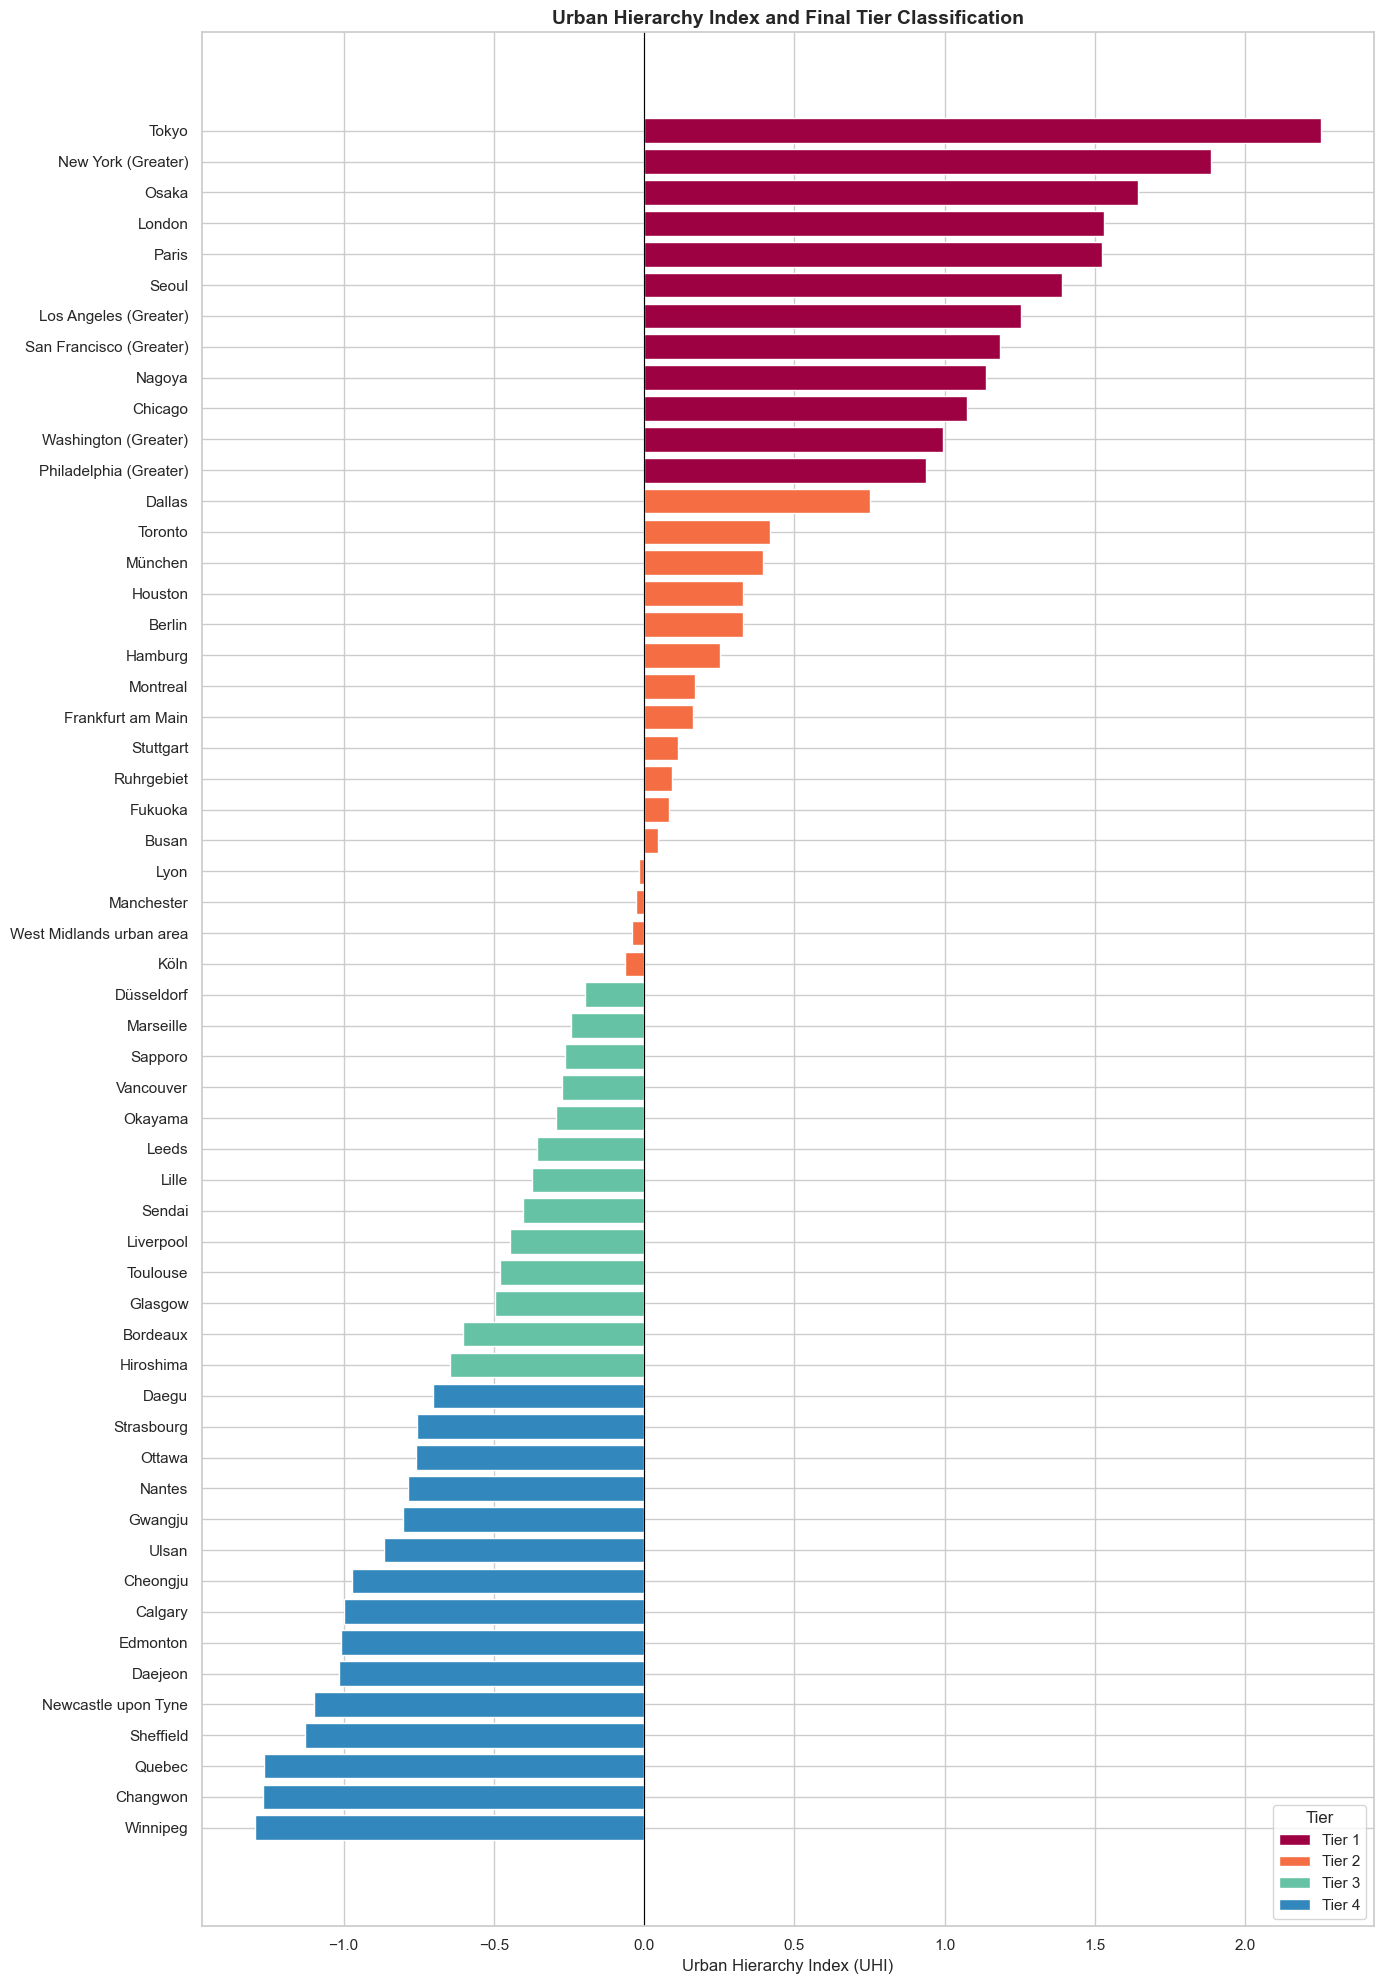

PNG saved to: /Users/cc-hoa/Desktop/毕业论文代码/results/Final_UHI_Tier_Ranking.png
PDF saved to: /Users/cc-hoa/Desktop/毕业论文代码/results/Final_UHI_Tier_Ranking.pdf


In [32]:
#UHI Ranking with Final Tier Classification
sns.set_theme(style="whitegrid")

tier_palette = {
    1: "#9E0142",
    2: "#F46D43",
    3: "#66C2A5",
    4: "#3288BD",
}

plot_data = df.sort_values(
    "UHI",
    ascending=True,
)

bar_colours = (
    plot_data["Tier_KMeans"]
    .map(tier_palette)
)

fig, axis = plt.subplots(
    figsize=(14, 20),
)

axis.barh(
    plot_data["FUA_Name"],
    plot_data["UHI"],
    color=bar_colours,
)

axis.axvline(
    x=0,
    color="black",
    linewidth=0.8,
)

axis.set_title(
    "Urban Hierarchy Index and Final Tier Classification",
    fontsize=14,
    fontweight="bold",
)

axis.set_xlabel(
    "Urban Hierarchy Index (UHI)"
)

axis.set_ylabel("")
# Add Tier Legend
from matplotlib.patches import Patch

legend_elements = [
    Patch(
        facecolor=tier_palette[tier],
        label=f"Tier {tier}",
    )
    for tier in sorted(tier_palette)
]

axis.legend(
    handles=legend_elements,
    title="Tier",
    loc="lower right",
)

# Figure Layout
fig.tight_layout()

# Save Figure
TIER_RANKING_PNG = (
    OUTPUT_DIR
    / "Final_UHI_Tier_Ranking.png"
)

TIER_RANKING_PDF = (
    OUTPUT_DIR
    / "Final_UHI_Tier_Ranking.pdf"
)

fig.savefig(
    TIER_RANKING_PNG,
    dpi=600,
    bbox_inches="tight",
)

fig.savefig(
    TIER_RANKING_PDF,
    bbox_inches="tight",
)

plt.show()
plt.close(fig)

print(
    f"PNG saved to: {TIER_RANKING_PNG}"
)

print(
    f"PDF saved to: {TIER_RANKING_PDF}"
)

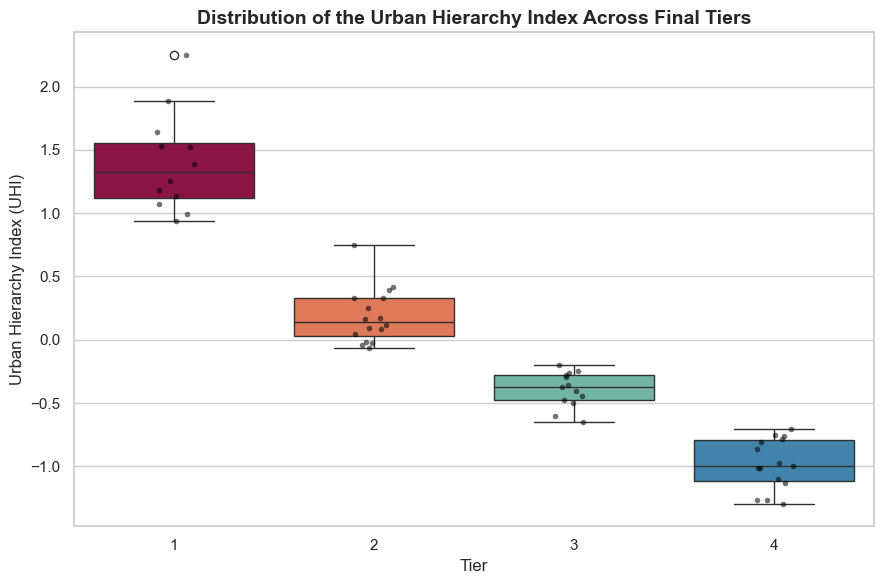

PNG saved to: /Users/cc-hoa/Desktop/毕业论文代码/results/Final_Tier_Boxplots.png
PDF saved to: /Users/cc-hoa/Desktop/毕业论文代码/results/Final_Tier_Boxplots.pdf


In [33]:
# 16. Distribution of UHI Across Final Tiers
fig, axis = plt.subplots(
    figsize=(9, 6),
)

sns.boxplot(
    data=df,
    x="Tier_KMeans",
    y="UHI",
    hue="Tier_KMeans",
    palette=tier_palette,
    legend=False,
    ax=axis,
)

sns.stripplot(
    data=df,
    x="Tier_KMeans",
    y="UHI",
    color="black",
    alpha=0.55,
    size=4,
    ax=axis,
)

axis.set_title(
    "Distribution of the Urban Hierarchy Index Across Final Tiers",
    fontsize=14,
    fontweight="bold",
)

axis.set_xlabel("Tier")
axis.set_ylabel("Urban Hierarchy Index (UHI)")

fig.tight_layout()

# Save Figure
BOXPLOT_PNG = (
    OUTPUT_DIR
    / "Final_Tier_Boxplots.png"
)

BOXPLOT_PDF = (
    OUTPUT_DIR
    / "Final_Tier_Boxplots.pdf"
)

fig.savefig(
    BOXPLOT_PNG,
    dpi=600,
    bbox_inches="tight",
)

fig.savefig(
    BOXPLOT_PDF,
    bbox_inches="tight",
)

plt.show()
plt.close(fig)

print(
    f"PNG saved to: {BOXPLOT_PNG}"
)

print(
    f"PDF saved to: {BOXPLOT_PDF}"
)

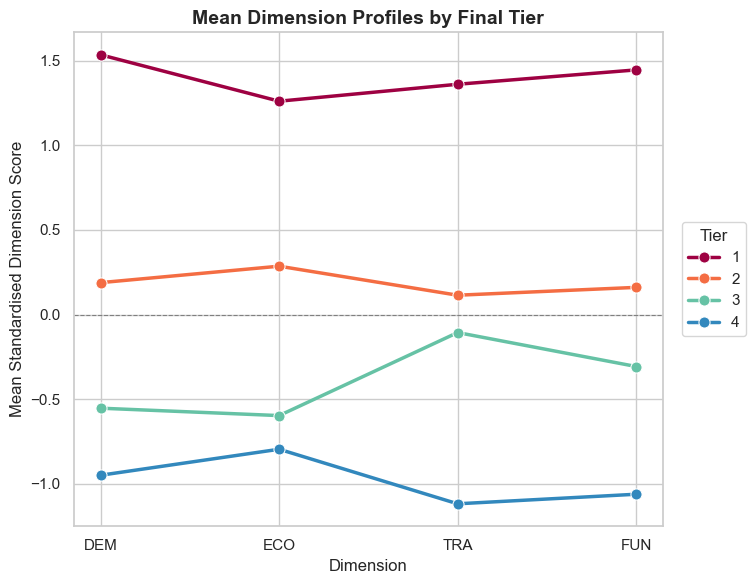

PNG saved to: /Users/cc-hoa/Desktop/毕业论文代码/results/Final_Tier_Dimension_Profiles.png
PDF saved to: /Users/cc-hoa/Desktop/毕业论文代码/results/Final_Tier_Dimension_Profiles.pdf


In [36]:
#Mean Dimension Profiles by Final Tier
profile_data = tier_summary[
    [
        "Tier",
        "Mean_DEM",
        "Mean_ECO",
        "Mean_TRA",
        "Mean_FUN",
    ]
].melt(
    id_vars="Tier",
    var_name="Dimension",
    value_name="Mean_Score",
)

profile_data["Dimension"] = (
    profile_data["Dimension"]
    .str.replace("Mean_", "", regex=False)
)

# Plot
fig, axis = plt.subplots(
    figsize=(9, 6),
)

sns.lineplot(
    data=profile_data,
    x="Dimension",
    y="Mean_Score",
    hue="Tier",
    palette=tier_palette,
    marker="o",
    linewidth=2.5,
    markersize=8,
    ax=axis,
)

axis.axhline(
    y=0,
    color="grey",
    linestyle="--",
    linewidth=0.8,
)

axis.set_title(
    "Mean Dimension Profiles by Final Tier",
    fontsize=14,
    fontweight="bold",
)

axis.set_xlabel("Dimension")

axis.set_ylabel(
    "Mean Standardised Dimension Score"
)

#Move Legend Outside
axis.legend(
    title="Tier",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=True,
)

#Layout
fig.tight_layout(
    rect=[0, 0, 0.86, 1]
)

#Save Figure
PROFILE_PNG = (
    OUTPUT_DIR
    / "Final_Tier_Dimension_Profiles.png"
)

PROFILE_PDF = (
    OUTPUT_DIR
    / "Final_Tier_Dimension_Profiles.pdf"
)

fig.savefig(
    PROFILE_PNG,
    dpi=600,
    bbox_inches="tight",
)

fig.savefig(
    PROFILE_PDF,
    bbox_inches="tight",
)

plt.show()
plt.close(fig)

print(f"PNG saved to: {PROFILE_PNG}")
print(f"PDF saved to: {PROFILE_PDF}")